# Phase 2: Hydrodynamics of Trapped Bose-Fermi Mixtures ($^{85}$Rb - $^{40}$K)

This notebook analyzes the density profiles of a co-trapped Bose-Fermi mixture under varying interspecies interactions ($a_{BF}$). 

### Theoretical Assumptions
The numerical models and plots below rely on the following physical approximations:

1. **Zero Temperature ($T = 0$):** We assume a pure Bose-Einstein Condensate (no thermal fraction) and a fully degenerate Fermi gas.

2. **Thomas-Fermi (TF) Limit for Bosons:** We neglect the quantum pressure (kinetic energy) term $-\frac{\hbar^2}{2m}\nabla^2\Psi_B$. This is valid for a large number of bosons ($N_B \gg 1$) where interaction energy dominates the kinetic energy.

3. **Local Density Approximation (LDA) for Fermions:** We treat the fermions hydrodynamically, assuming the gas reaches a local equilibrium where the local chemical potential depends strictly on the local density $n_F(r)$ via the Fermi energy formula.

4. **Mean-Field Interactions:** We assume interactions are fully described by the s-wave scattering lengths ($a_B, a_{BF}$) and ignore beyond-mean-field corrections (like Lee-Huang-Yang quantum fluctuations).

5. **Isotropic Harmonic Trap:** We assume a spherically symmetric trapping potential $V(r) = \frac{1}{2}m\omega^2r^2$. We also assume that both species experience the same trap frequency $\omega = 2 \pi f$ for simplicity.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def solve_mixture_rigorous(aB_a0, aBF_a0, mB_amu, mF_amu, freq_Hz, NB, NF, num_pts=5000):
    """
    Solves the coupled TF and LDA equations for a Bose-Fermi mixture.
    Returns the radial grid, real bosonic density, and real fermionic density.
    """
    # --- Physical Constants ---
    amu = 1.660539e-27  # kg
    a0 = 5.291772e-11   # Bohr radius (m)
    hbar = 1.054571e-34 # J*s
    um = 1e-6           # Micron scale

    omega = 2 * np.pi * freq_Hz
    mB, mF = mB_amu * amu, mF_amu * amu
    aB, aBF = aB_a0 * a0, aBF_a0 * a0

    # --- Calculate Couplings (SI units) ---
    gB_si = (4 * np.pi * hbar ** 2 * aB) / mB
    mu_red = (mB * mF) / (mB + mF)
    gBF_si = (2 * np.pi * hbar ** 2 * aBF) / mu_red

    # Grid out to 50 microns
    r = np.linspace(0, 50 * um, num_pts)
    dV = 4 * np.pi * r ** 2

    VB = 0.5 * mB * omega ** 2 * r ** 2
    VF = 0.5 * mF * omega ** 2 * r ** 2

    nB, nF = np.zeros_like(r), np.zeros_like(r)

    # Iterative solver with Bisection for Rigorous Normalization
    for i in range(500):
        # 1. Solve for muB given current nF
        def get_nB(mu):
            return np.maximum(0, (mu - VB - gBF_si * nF) / gB_si)

        low, high = 0, 1e-25
        for _ in range(40):
            mid = (low + high) / 2
            if np.trapezoid(get_nB(mid) * dV, r) < NB: low = mid
            else: high = mid
        nB_new = get_nB(high)

        # 2. Solve for muF given current nB
        def get_nF(mu):
            eff_mu = np.maximum(0, mu - VF - gBF_si * nB_new)
            return (1 / (6 * np.pi ** 2)) * (2 * mF / hbar ** 2 * eff_mu) ** 1.5

        low, high = 0, 1e-25
        for _ in range(40):
            mid = (low + high) / 2
            if np.trapezoid(get_nF(mid) * dV, r) < NF: low = mid
            else: high = mid
        nF_new = get_nF(high)

        # 3. Damping for smooth convergence
        delta = np.max(np.abs(nB - nB_new))
        nB = 0.9 * nB + 0.1 * nB_new
        nF = 0.9 * nF + 0.1 * nF_new

        if delta < 1e-45 and i > 50: break

    # Returns r in microns and real density in particles per um^3
    return r / um, nB * (um ** 3), nF * (um ** 3)

def extract_metrics(r_um, nb, nf):
    """Extracts central density and Thomas-Fermi radii."""
    nB_center = nb[0]
    nF_center = nf[0]
    
    # Radius is the last point where density is greater than a tiny threshold
    rB_idx = np.where(nb > 1e-3)[0][-1] if np.any(nb > 1e-3) else 0
    rF_idx = np.where(nf > 1e-3)[0][-1] if np.any(nf > 1e-3) else 0
    
    return nB_center, nF_center, r_um[rB_idx], r_um[rF_idx]

In [32]:
# --- Parameters (85Rb and 40K) ---
mB, mF = 85.0, 40.0
trap_freq = 50.0  # Hz
NB, NF = 500000, 500000 
aB_a0 = 100.0

aBF_a0_values = [0.0, -150.0, 20.0, 150.0]  # in units of a0

regimes = [
    (aBF_a0_values[0], "Non-interacting ($a_{BF} = $" + f"${aBF_a0_values[0]} a_0$)"),
    (aBF_a0_values[1], "Attractive ($a_{BF} = $" + f"${aBF_a0_values[1]} a_0$)"),
    (aBF_a0_values[2], "Weak_Repulsion ($a_{BF} = $" + f"${aBF_a0_values[2]} a_0$)"),
    (aBF_a0_values[3], "Phase_Separation ($a_{BF} = $" + f"${aBF_a0_values[3]} a_0$)"),
]

# Dictionary to store results for plotting
results = {}

print(f"{'Regime':<20} | {'nB(0)':<10} | {'nF(0)':<10} | {'RB_TF (um)':<10} | {'RF_TF (um)':<10}")
print("-" * 70)

for aBF_val, title in regimes:
    r_um, nb_real, nf_real = solve_mixture_rigorous(aB_a0, aBF_val, mB, mF, trap_freq, NB, NF)
    nB0, nF0, RB, RF = extract_metrics(r_um, nb_real, nf_real)
    
    results[title] = (r_um, nb_real, nf_real)
    
    regime_name = title.split(" ")[0]
    print(f"{regime_name:<20} | {nB0:<10.1f} | {nF0:<10.1f} | {RB:<10.2f} | {RF:<10.2f}")

Regime               | nB(0)      | nF(0)      | RB_TF (um) | RF_TF (um)
----------------------------------------------------------------------
Non-interacting      | 183.7      | 7.3        | 11.75      | 38.13     
Attractive           | 194.1      | 13.2       | 11.55      | 37.94     
Weak_Repulsion       | 183.6      | 6.6        | 11.75      | 38.15     
Phase_Separation     | 188.6      | 2.8        | 11.63      | 38.29     


### Analysis of the Hydrodynamic Behaviors

Based on the numerical output generated above, we can draw the following physical insights regarding the atomic density at the trap center ($n(0)$) and the sample size (Thomas-Fermi radii, $R_{TF}$) as the interspecies interaction $a_{BF}$ deviates from zero while $a_{B} = 100\ a_{0}$:

1. **Non-interacting Regime ($a_{BF} = 0$):** This is our baseline. The bosons and fermions overlap freely, bound only by the external trap and their own internal pressures (bosonic repulsion and Fermi pressure, respectively).

2. **Attractive Regime ($a_{BF} = - 150\ a_0$):**
   * **Central Density:** Spikes significantly for both species. The mutual attraction acts as an effective trapping force pulling the species toward the center $r=0$.
   * **Sample Size ($R_{TF}$):** Shrinks for both species. The overall volume of both clouds contracts to balance the strong inward pull.

3. **Weak Repulsion ($a_{BF} = 30\ a_0$):**
   * **Central Density:** Fermion density drops slightly compared to the baseline but boson density is comparable. The species push against each other, displacing particles outward.
   * **Sample Size ($R_{TF}$):** Expands slightly as the internal pressure of the mixture increases.
      * Thomas-Fermi radius for bosons is unchanged and slighlty larger for fermions.

4. **Phase Separation ($a_{BF} = 150\ a_0$):**
   * **Central Density:** The boson density at the center remains extremely high, while there is a big drop in the fermion density at the center.
   * **Sample Size ($R_{TF}$):** The BEC acts as an impermeable "plunger," pushing the fermions entirely out of the trap center. The fermions form a shell around the bosons, causing the fermionic $R_{TF}$ to be larger than the baseline of the non-interacting case.

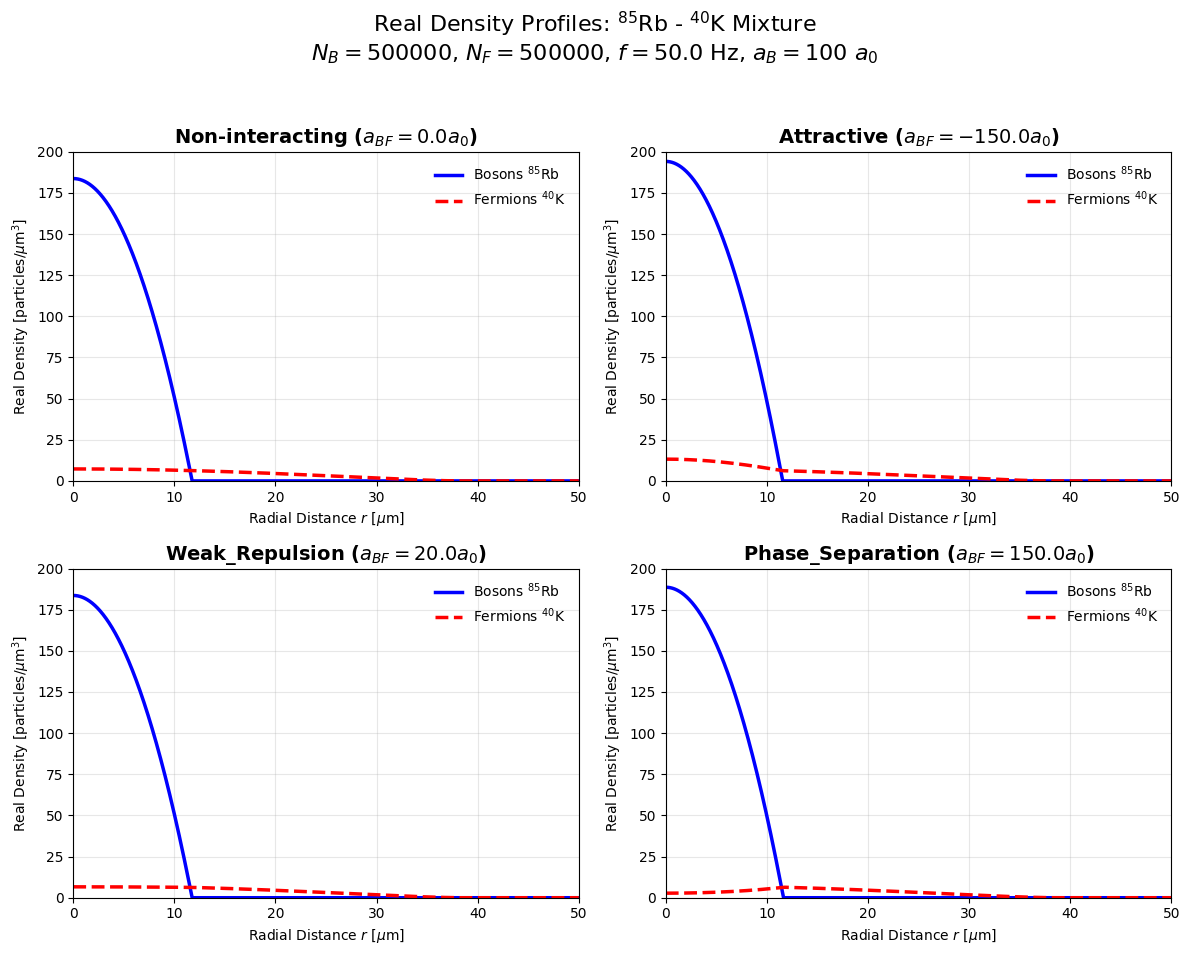

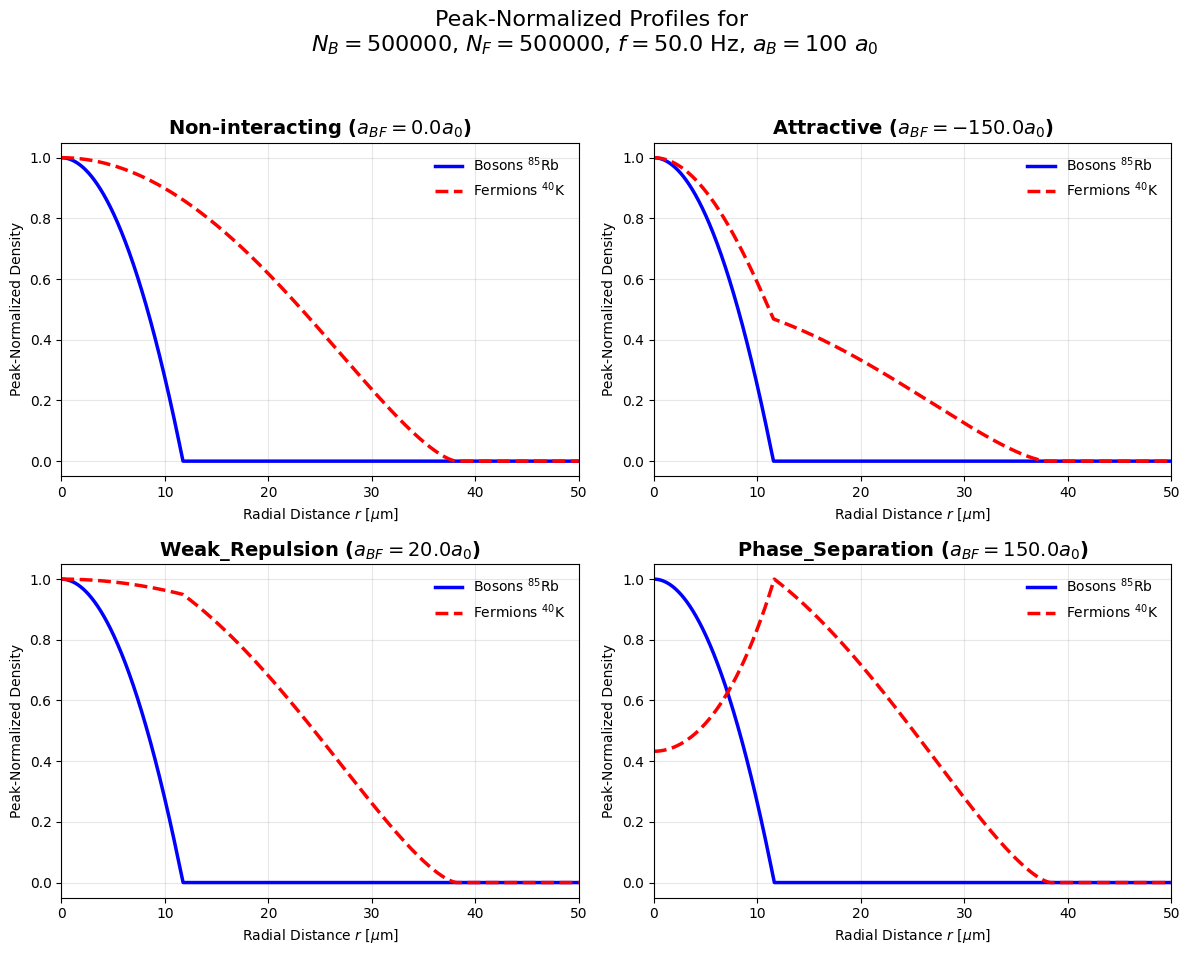

In [34]:
# --- Real Density Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (title, (r_um, nb_real, nf_real)) in enumerate(results.items()):
    axes[i].plot(r_um, nb_real, color='blue', lw=2.5, label=r'Bosons $^{85}$Rb')
    axes[i].plot(r_um, nf_real, color='red', ls='--', lw=2.5, label=r'Fermions $^{40}$K')
    axes[i].set_title(title, fontweight='bold', fontsize=14)
    axes[i].set_xlabel(r'Radial Distance $r$ [$\mu$m]')
    axes[i].set_ylabel(r'Real Density [particles/$\mu$m$^3$]')
    axes[i].legend(frameon=False)
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(0, 50)
    axes[i].set_ylim(0, 200) # Keep scale consistent for real density

plt.suptitle("Real Density Profiles: $^{85}$Rb - $^{40}$K Mixture \n"
             f"$N_B={NB}$, $N_F={NF}$, $f={trap_freq}$ Hz, $a_B = 100\ a_0$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Peak-Normalized Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (title, (r_um, nb_real, nf_real)) in enumerate(results.items()):
    # Normalize on the fly for the second plot
    nb_peak = nb_real / np.max(nb_real) if np.max(nb_real) > 0 else nb_real
    nf_peak = nf_real / np.max(nf_real) if np.max(nf_real) > 0 else nf_real
    
    axes[i].plot(r_um, nb_peak, color='blue', lw=2.5, label='Bosons $^{85}$Rb')
    axes[i].plot(r_um, nf_peak, color='red', ls='--', lw=2.5, label='Fermions $^{40}$K')
    axes[i].set_title(title, fontweight='bold', fontsize=14)
    axes[i].set_xlabel(r'Radial Distance $r$ [$\mu$m]')
    axes[i].set_ylabel('Peak-Normalized Density')
    axes[i].legend(frameon=False)
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(0, 50)
    axes[i].set_ylim(-0.05, 1.05)

plt.suptitle(f"Peak-Normalized Profiles for \n"
             f"$N_B={NB}$, $N_F={NF}$, $f={trap_freq}$ Hz, $a_B = 100\ a_0$", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()